# American Sign Language (ASL) Detection
This notebook builds a CNN-based model to classify ASL alphabet images (29 classes).

In [40]:
pip install tensorflow keras numpy matplotlib opencv-python

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [44]:
import os

# Paths
# Corrected train_dir to access the actual training image folders
train_dir = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
# Keep test_dir pointing to the original sparse test set for potential future use (e.g., specific predictions)
test_dir = os.path.join(path, 'asl_alphabet_test')

IMG_SIZE = 32 # Reduced image size to significantly speed up training
BATCH_SIZE = 128 # Increased batch size to further speed up training
EPOCHS = 15


In [46]:
print(f"Contents of original test directory ({test_dir}):")
try:
    test_files = os.listdir(test_dir)
    if test_files:
        print(f"  First 10 files: {test_files[:10]}...")
        print(f"  Total files found: {len(test_files)}")
    else:
        print("  Directory is empty.")
except FileNotFoundError:
    print(f"  Error: Directory not found at {test_dir}")
except Exception as e:
    print(f"  An error occurred: {e}")


Contents of original test directory (/kaggle/input/asl-alphabet/asl_alphabet_test):
  First 10 files: ['asl_alphabet_test']...
  Total files found: 1


In [34]:
# This cell previously contained code to restructure the test directory.
# It is no longer needed as we are using a validation split from the training data.
# Keeping it empty or commented out to avoid errors.
# If you wish to use the original test set for specific predictions later,
# 'test_dir' still points to it as defined in the previous cell.

In [45]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # Allocate 20% of training data for validation
)

# We will use the same datagen to create both training and validation sets from 'train_dir'

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' # Specify this is for the training subset
)

test_data = train_datagen.flow_from_directory( # Renamed 'validation_data' to 'test_data' for consistency with model.fit
    train_dir, # Use the same directory as training for the validation subset
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation', # Specify this is for the validation subset
    shuffle=False # Keep data in order for evaluation if needed
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [47]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(29, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,653 (635.36 KB)

 Trainable params: 162,653 (635.36 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(29, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,653 (635.36 KB)

 Trainable params: 162,653 (635.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 272s 495ms/step - accuracy: 0.2343 - loss: 2.5620 - val_accuracy: 0.3851 - val_loss: 2.0415
Epoch 2/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 270s 497ms/step - accuracy: 0.5330 - loss: 1.4354 - val_accuracy: 0.5143 - val_loss: 1.4958
Epoch 3/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 282s 519ms/step - accuracy: 0.6576 - loss: 1.0297 - val_accuracy: 0.5666 - val_loss: 1.3005
Epoch 4/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 274s 503ms/step - accuracy: 0.7231 - loss: 0.8132 - val_accuracy: 0.6154 - val_loss: 1.1926
Epoch 5/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 269s 494ms/step - accuracy: 0.7676 - loss: 0.6820 - val_accuracy: 0.6363 - val_loss: 1.1262
Epoch 6/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 269s 494ms/step - accuracy: 0.7970 - loss: 0.5914 - val_accuracy: 0.6721 - val_loss: 1.0852
Epoch 7/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 271s 498ms/step - accuracy: 0.8187 - loss: 0.5243 - val_accuracy: 0.6822 - val_loss: 1.0424
Epoch 8/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 270s 497ms/step - accuracy: 0.8403 -

In [50]:
model.save('asl_model.h5')

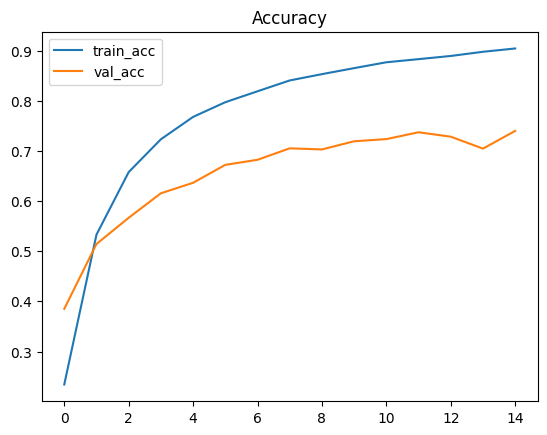

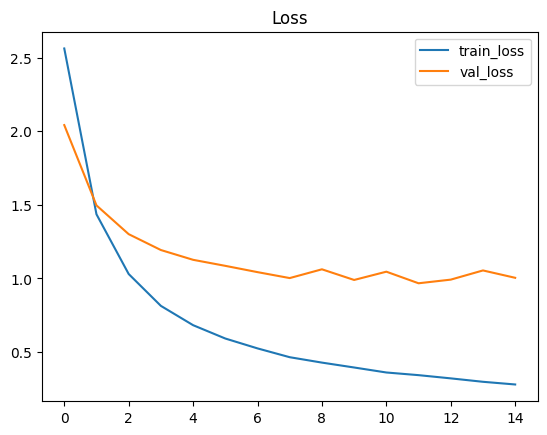

In [51]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

In [52]:
class_labels = list(train_data.class_indices.keys())

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.reshape(img, (1, IMG_SIZE, IMG_SIZE, 3))

    prediction = model.predict(img)
    predicted_class = class_labels[np.argmax(prediction)]

    print('Predicted Sign:', predicted_class)

# Example
# predict_image('test_image.jpg')

## 9. Test Prediction

Let's test our trained model on a sample image from the test set to see its prediction.

In [53]:
# The 'test_dir' from our setup was originally '/kaggle/input/asl-alphabet/asl_alphabet_test'.
# Inspecting its content previously showed a nested folder 'asl_alphabet_test'.
# Let's define the actual path to the test images.

# Adjust test_dir to point to the actual folder containing images if it's nested
# Based on previous output `os.listdir(test_dir)` = `['asl_alphabet_test']`,
# the structure seems to be `asl_alphabet_test/asl_alphabet_test/*.jpg`
actual_test_images_dir = os.path.join(test_dir, 'asl_alphabet_test')

# List files in this directory to pick a sample image
if os.path.exists(actual_test_images_dir) and os.listdir(actual_test_images_dir):
    sample_test_image = os.path.join(actual_test_images_dir, os.listdir(actual_test_images_dir)[0])
    print(f"Using sample test image: {sample_test_image}")
    predict_image(sample_test_image)
else:
    print(f"Could not find any images in {actual_test_images_dir} for prediction.")
    print("Please ensure the test directory contains images or upload a sample image to test.")


Using sample test image: /kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test/A_test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Predicted Sign: A


## 10. Model Evaluation

Let's evaluate the model's performance on the validation dataset (which we've named `test_data` here) to get a comprehensive understanding of its accuracy and loss.

In [54]:
loss, accuracy = model.evaluate(test_data)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 376ms/step - accuracy: 0.7386 - loss: 0.9953
Validation Loss: 0.9953
Validation Accuracy: 0.7386


### Classification Report and Confusion Matrix

To get a more detailed view of the model's performance, especially per-class metrics and common misclassifications, we'll generate a classification report and a confusion matrix.

136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 376ms/step
Classification Report:
              precision    recall  f1-score   support

           A       0.87      0.67      0.75       600
           B       0.76      0.92      0.83       600
           C       0.95      0.89      0.92       600
           D       0.95      0.80      0.87       600
           E       0.74      0.72      0.73       600
           F       0.87      0.94      0.91       600
           G       0.79      0.78      0.79       600
           H       0.78      0.89      0.83       600
           I       0.96      0.53      0.69       600
           J       0.88      0.78      0.82       600
           K       0.97      0.88      0.92       600
           L       0.90      0.97      0.94       600
           M       0.48      0.60      0.53       600
           N       0.32      0.46      0.38       600
           O       0.74      0.62      0.67       600
           P       0.69      0.79      0.73       600
           Q  

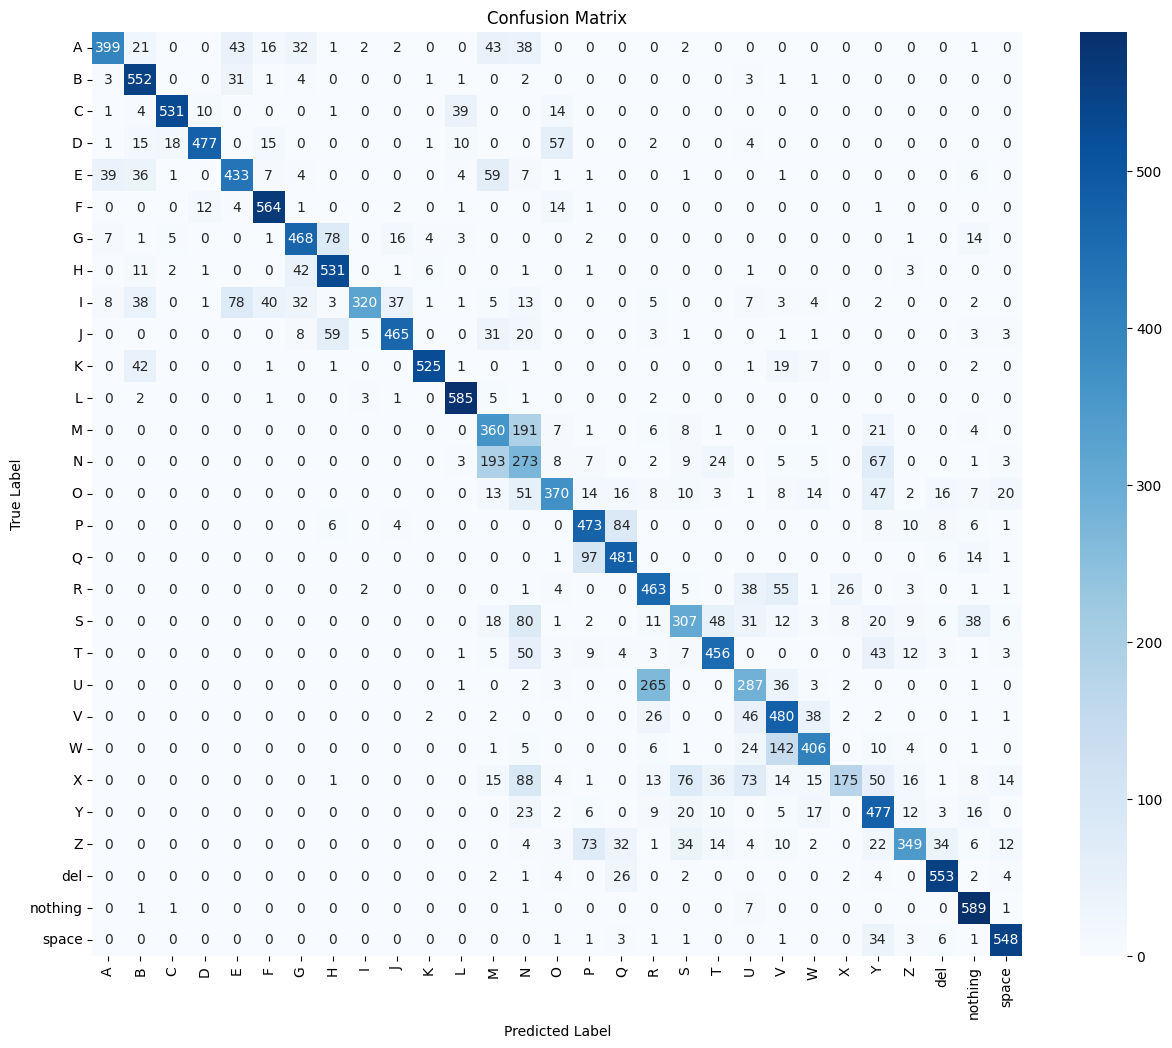

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # Import seaborn for heatmap visualization

# Get true labels
y_true = test_data.classes

# Get predicted probabilities
y_pred_prob = model.predict(test_data)

# Get predicted labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()